In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score)
from imblearn.over_sampling import SMOTE 

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

DATA_FILE = "bank-additional-full.csv"
TARGET_COL = "y"
NUMERICAL_COLS = ["age", "duration", "campaign", "previous", "emp.var.rate", 
                  "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

In [44]:

df = pd.read_csv(DATA_FILE, sep=";")
print(f"✅ Data Loaded. Shape: {df.shape}")
display(df.head()) 

df = df.drop_duplicates().reset_index(drop=True)

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace("unknown", df[col].mode()[0])

for col in NUMERICAL_COLS:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = np.clip(df[col], Q1 - 1.5*IQR, Q3 + 1.5*IQR)

print("✅ Data Cleaning Completed: Duplicates removed, Unknowns handled, Outliers capped.")

✅ Data Loaded. Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


✅ Data Cleaning Completed: Duplicates removed, Unknowns handled, Outliers capped.


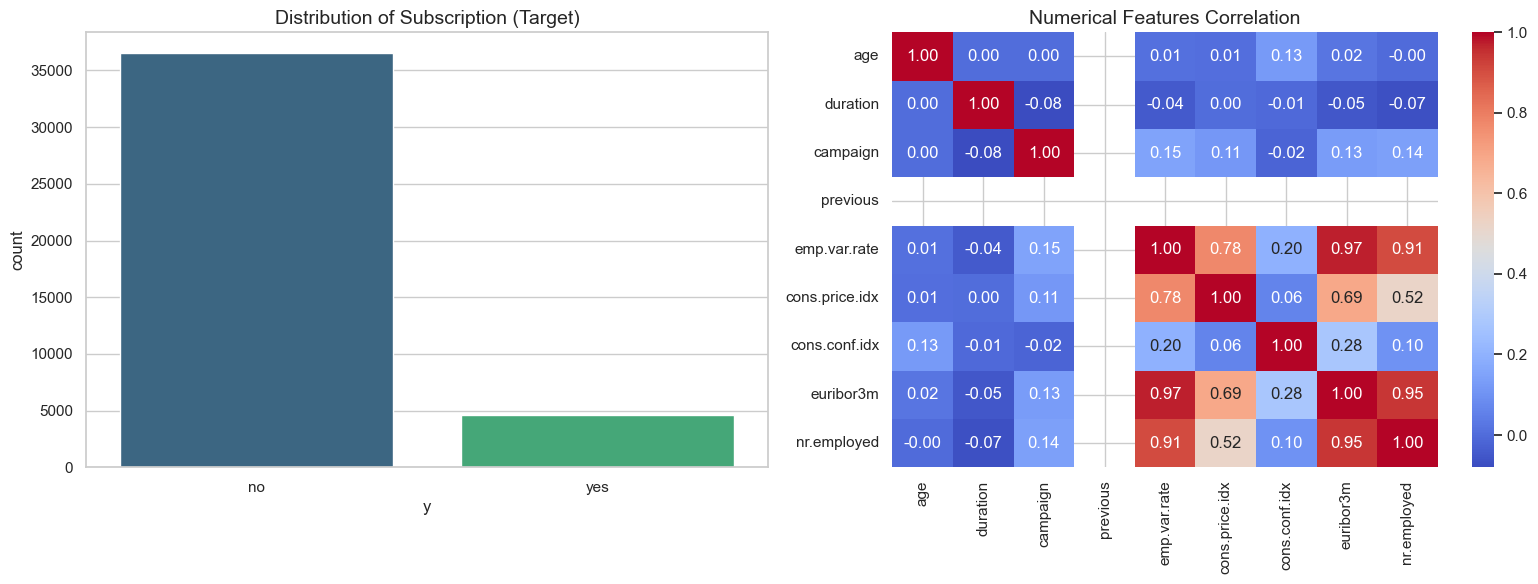

In [45]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.countplot(x=TARGET_COL, data=df, palette="viridis")
plt.title("Distribution of Subscription (Target)", fontsize=14)

plt.subplot(1, 2, 2)
sns.heatmap(df[NUMERICAL_COLS].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Numerical Features Correlation", fontsize=14)

plt.tight_layout()
plt.show()

In [46]:

cat_cols = [c for c in df.select_dtypes(include="object").columns if c != TARGET_COL]
df_final = pd.get_dummies(df, columns=cat_cols, drop_first=True)

y = LabelEncoder().fit_transform(df[TARGET_COL])
X = df_final.drop(TARGET_COL, axis=1)
feature_names = X.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print("✅ Encoding, Scaling, and Split Completed.")

✅ Encoding, Scaling, and Split Completed.


Applying SMOTE to balance the training set...


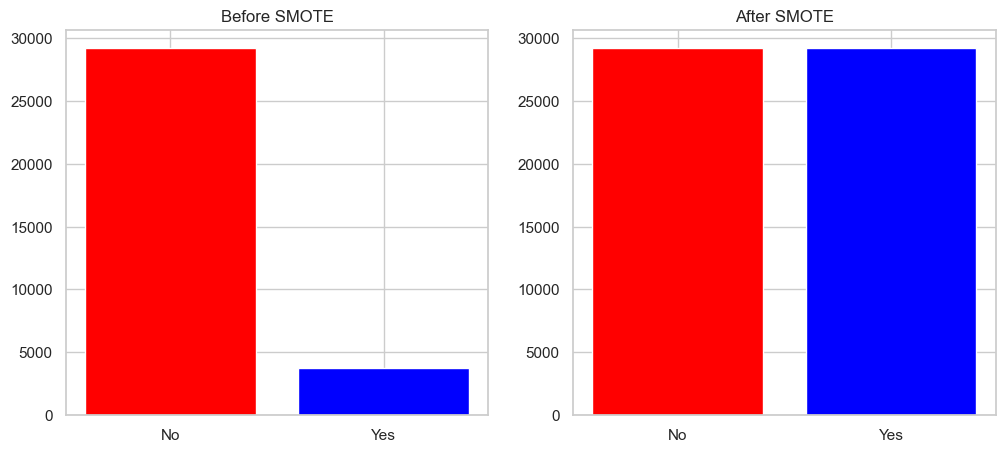

In [47]:
print("Applying SMOTE to balance the training set...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

labels = ['No', 'Yes']
before = np.bincount(y_train)
after = np.bincount(y_train_res)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].bar(labels, before, color=['red', 'blue'])
ax[0].set_title("Before SMOTE")
ax[1].bar(labels, after, color=['red', 'blue'])
ax[1].set_title("After SMOTE")
plt.show()

In [48]:

selector = SelectKBest(score_func=f_classif, k=15)
X_train_sel = selector.fit_transform(X_train_res, y_train_res)
X_test_sel = selector.transform(X_test)

selected_features = np.array(feature_names)[selector.get_support()]
print("✅ Top 15 Features Selected for Modeling:\n", selected_features)

✅ Top 15 Features Selected for Modeling:
 ['duration' 'campaign' 'pdays' 'emp.var.rate' 'cons.price.idx' 'euribor3m'
 'nr.employed' 'job_blue-collar' 'contact_telephone' 'month_mar'
 'month_may' 'month_oct' 'month_sep' 'poutcome_nonexistent'
 'poutcome_success']



--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.85      0.91      7308
           1       0.43      0.91      0.59       928

    accuracy                           0.85      8236
   macro avg       0.71      0.88      0.75      8236
weighted avg       0.92      0.85      0.88      8236


--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.87      0.92      7308
           1       0.46      0.85      0.60       928

    accuracy                           0.87      8236
   macro avg       0.72      0.86      0.76      8236
weighted avg       0.92      0.87      0.89      8236


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      7308
           1       0.52      0.65      0.58       928

    accuracy                           0.

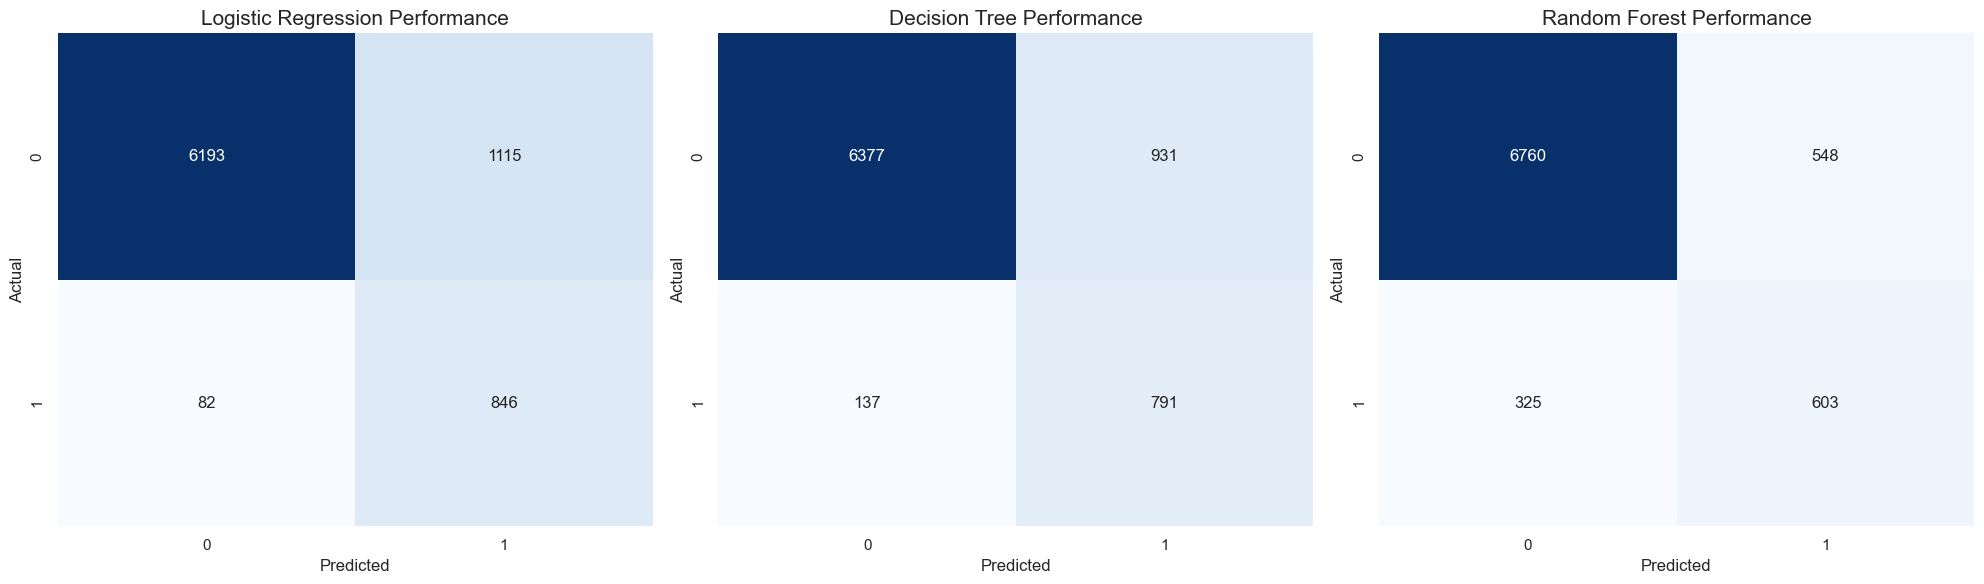

In [49]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

plt.figure(figsize=(20, 6))

for i, (name, model) in enumerate(models.items(), 1):
    model.fit(X_train_sel, y_train_res)
    y_pred = model.predict(X_test_sel)
    
    plt.subplot(1, 3, i)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"{name} Performance", fontsize=15)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    print(f"\n--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred))

plt.tight_layout()
plt.show()

In [32]:
print("Running Cross-Validation (5-Folds) to ensure stability:")
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_sel, y_train_res, cv=5)
    print(f"    → {name} Average Accuracy: {cv_scores.mean():.4f}")

Running Cross-Validation (5-Folds) to ensure stability:
    → Logistic Regression Average Accuracy: 0.8810
    → Decision Tree Average Accuracy: 0.9025
    → Random Forest Average Accuracy: 0.9225


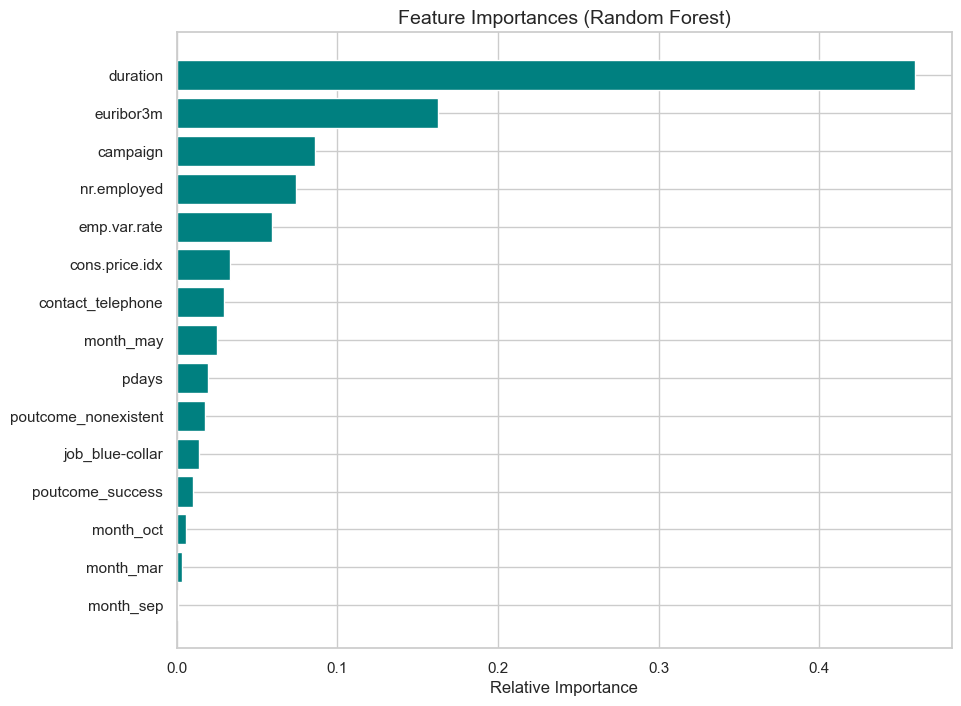

In [33]:
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.title("Feature Importances (Random Forest)", fontsize=14)
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [selected_features[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

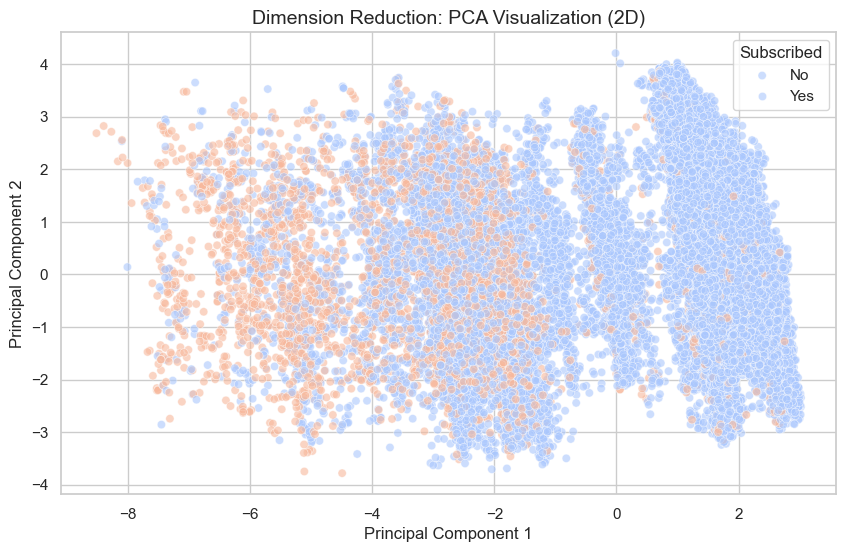

In [50]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='coolwarm', alpha=0.6)
plt.title('Dimension Reduction: PCA Visualization (2D)', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Subscribed', labels=['No', 'Yes'])
plt.show()

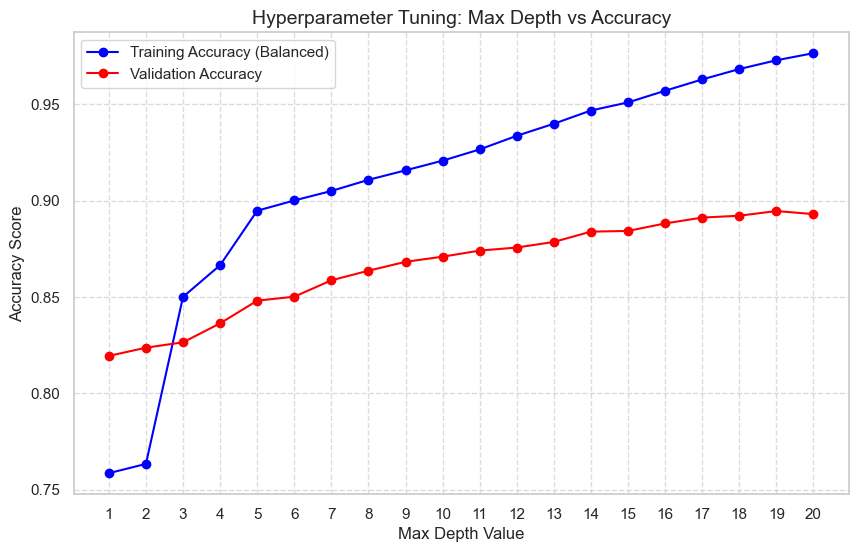

In [51]:

depths = range(1, 21)
train_scores = []
test_scores = []

for d in depths:
    model = RandomForestClassifier(max_depth=d, n_estimators=100, random_state=42, class_weight='balanced')
    model.fit(X_train_sel, y_train_res)
    train_scores.append(accuracy_score(y_train_res, model.predict(X_train_sel)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test_sel)))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, '-o', label='Training Accuracy (Balanced)', color='blue')
plt.plot(depths, test_scores, '-o', label='Validation Accuracy', color='red')
plt.title('Hyperparameter Tuning: Max Depth vs Accuracy', fontsize=14)
plt.xlabel('Max Depth Value')
plt.ylabel('Accuracy Score')
plt.xticks(depths)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()